In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv("data/employee_attrition.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [5]:
TARGET = "Attrition"

FEATURES = [
    "Age",
    "BusinessTravel",
    "Department",
    "DistanceFromHome",
    "Education",
    "EducationField",
    "EnvironmentSatisfaction",
    "Gender",
    "JobInvolvement",
    "JobLevel",
    "JobRole",
    "JobSatisfaction",
    "MaritalStatus",
    "MonthlyIncome",
    "NumCompaniesWorked",
    "OverTime",
    "PercentSalaryHike",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

X = df[FEATURES]
y = df[TARGET]

print("Number of Input Features:", len(FEATURES))
print("Target Column:", TARGET)

Number of Input Features: 27
Target Column: Attrition


In [6]:
missing_values = df[FEATURES + [TARGET]].isnull().sum().sum()
duplicate_rows = df.duplicated().sum()

print("Missing Values:", missing_values)
print("Duplicate Rows:", duplicate_rows)

Missing Values: 0
Duplicate Rows: 0


In [7]:
CATEGORICAL_FEATURES = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

NUMERIC_FEATURES = [
    feature for feature in FEATURES
    if feature not in CATEGORICAL_FEATURES
]

print("Categorical Features:", len(CATEGORICAL_FEATURES))
print("Numerical Features:", len(NUMERIC_FEATURES))

Categorical Features: 7
Numerical Features: 20


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 27)
Testing Data: (294, 27)


Logistic Regression

In [9]:
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", NUMERIC_FEATURES),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES
        )
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                solver="liblinear",
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [10]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    pos_label="Yes",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    pos_label="Yes",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    pos_label="Yes",
    zero_division=0
)

print("LOGISTIC REGRESSION RESULTS")
print("-" * 35)

print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

LOGISTIC REGRESSION RESULTS
-----------------------------------
Accuracy : 0.7619
Precision: 0.3614
Recall   : 0.6383
F1 Score : 0.4615


Random Forest

In [11]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", NUMERIC_FEATURES),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES
        )
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [12]:
rf_accuracy = accuracy_score(y_test, random_forest_predictions)

rf_precision = precision_score(
    y_test,
    random_forest_predictions,
    pos_label="Yes",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    random_forest_predictions,
    pos_label="Yes",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    random_forest_predictions,
    pos_label="Yes",
    zero_division=0
)

print("RANDOM FOREST RESULTS")
print("-" * 35)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

RANDOM FOREST RESULTS
-----------------------------------
Accuracy : 0.8503
Precision: 0.6667
Recall   : 0.1277
F1 Score : 0.2143


Model Comparison Table

In [13]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7619,0.3614,0.6383,0.4615
1,Random Forest,0.8503,0.6667,0.1277,0.2143


Comparison Graph

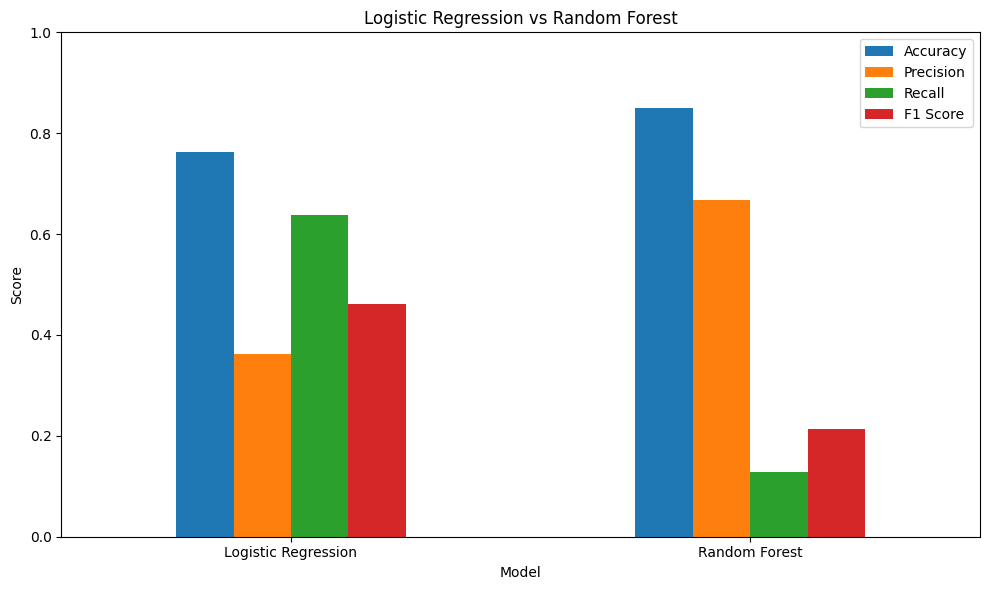

In [14]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Logistic Regression vs Random Forest")

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

Select Better Model

In [18]:
best_model = comparison.loc[
    comparison["F1 Score"].idxmax()
]

print("BEST MODEL")
print("=" * 30)

print("Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1 Score"])

BEST MODEL
Model: Logistic Regression
Accuracy: 0.7619
Precision: 0.3614
Recall: 0.6383
F1 Score: 0.4615


In [16]:
print("\nFINAL CONCLUSION")
print("=" * 50)

print(
    f"""
Both models were trained using:

• Same dataset
• Same 27 input features
• Same preprocessing
• Same 80-20 train-test split

The models were compared using:

• Accuracy
• Precision
• Recall
• F1 Score

Based on the F1 Score, the selected model is:

{best_model["Model"]}
"""
)


FINAL CONCLUSION

Both models were trained using:

• Same dataset
• Same 27 input features
• Same preprocessing
• Same 80-20 train-test split

The models were compared using:

• Accuracy
• Precision
• Recall
• F1 Score

Based on the F1 Score, the selected model is:

Logistic Regression

